In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [40]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [42]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [43]:
train_df.shape

(891, 12)

In [44]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [45]:
train_df.duplicated().sum()

np.int64(0)

In [46]:
train_df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

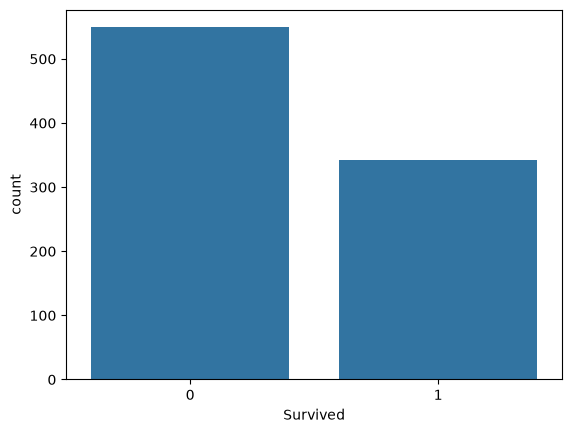

In [47]:
sns.countplot(
    data=train_df,
    x="Survived"
)

plt.show()

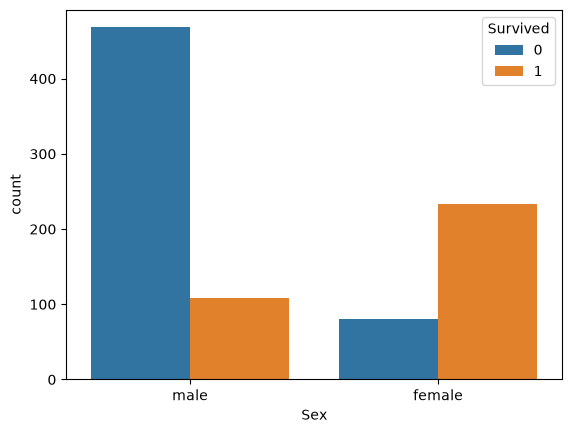

In [48]:
sns.countplot(
    data=train_df,
    x="Sex",
    hue="Survived"
)

plt.show()

In [49]:
train_df.select_dtypes(include="number").columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')

In [50]:
correlation = train_df.corr(numeric_only=True)

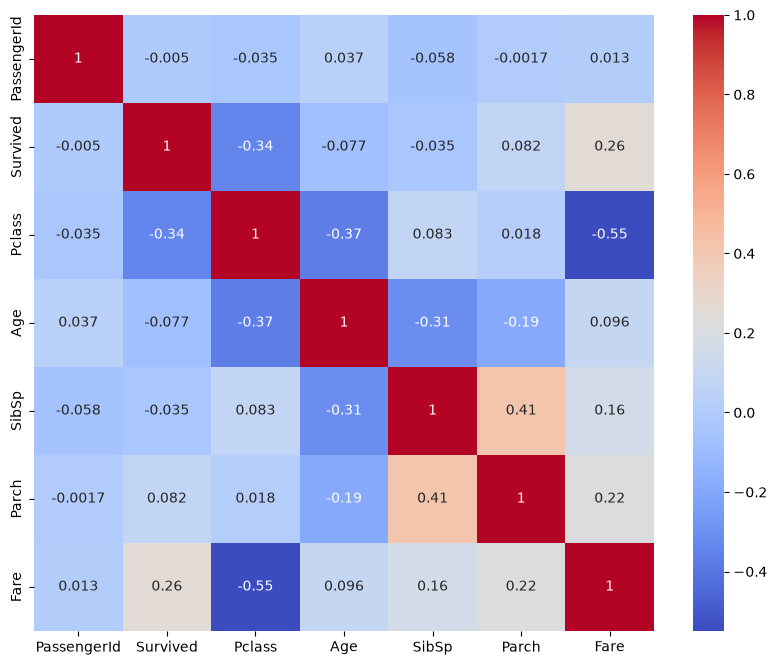

In [51]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
            )

plt.show()

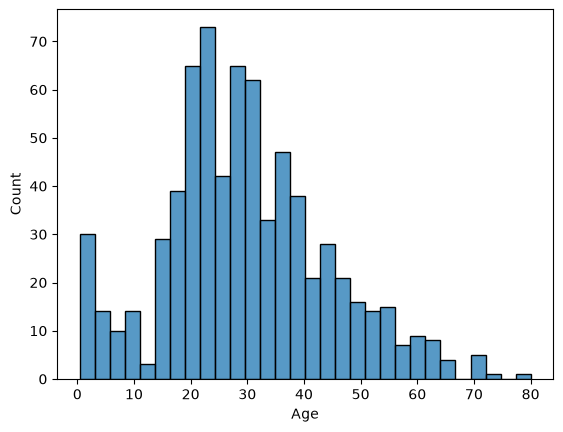

In [52]:
sns.histplot(train_df["Age"], bins=30)
plt.show()

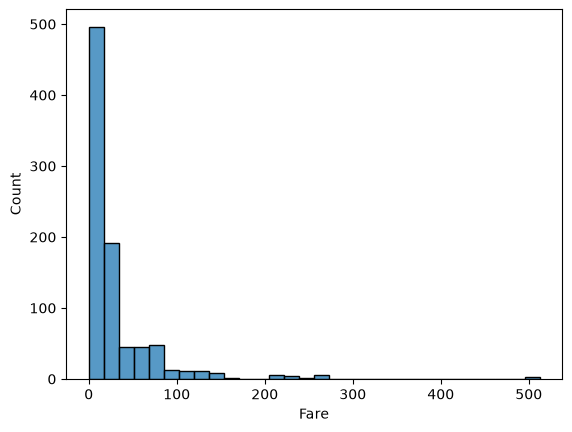

In [53]:
sns.histplot(train_df["Fare"], bins=30)
plt.show()

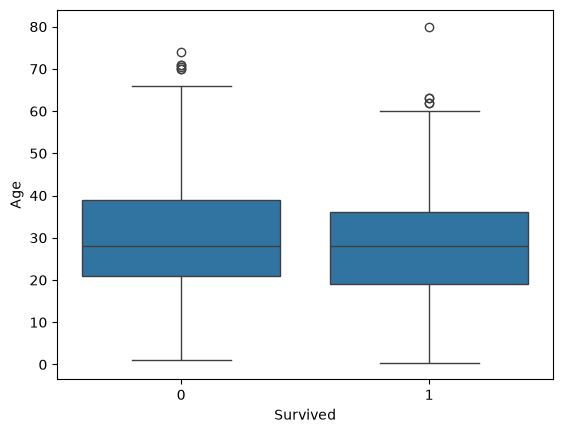

In [54]:
sns.boxplot(
    data=train_df,
    x="Survived",
    y="Age"
)

plt.show()

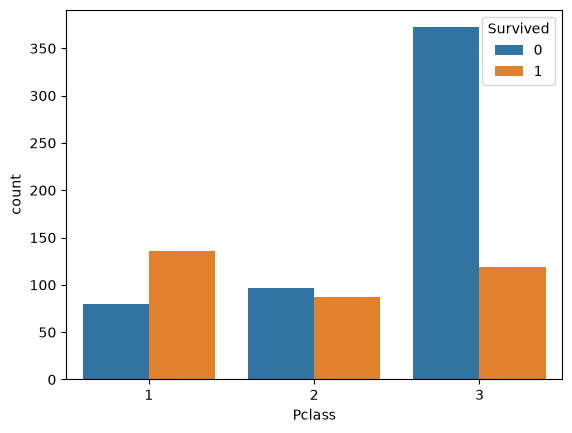

In [55]:
sns.countplot(
    data=train_df,
    x="Pclass",
    hue="Survived"
)

plt.show()

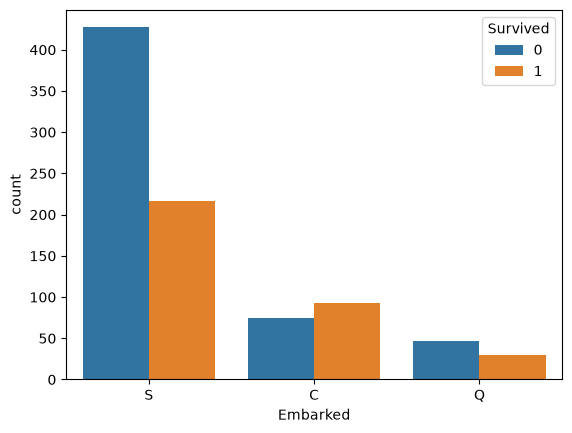

In [56]:
sns.countplot(
    data=train_df,
    x="Embarked",
    hue="Survived"
)

plt.show()

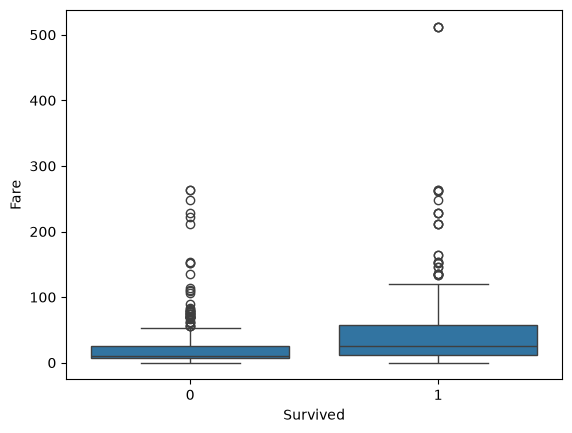

In [57]:
sns.boxplot(
    data=train_df,
    x="Survived",
    y="Fare"
)

plt.show()

In [58]:
df = train_df.copy()

In [59]:
df = df.drop(columns=["PassengerId"])
df = df.drop(columns=["Name"])
df = df.drop(columns=["Ticket"])

In [60]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [61]:
df.drop(columns=["SibSp", "Parch"], inplace=True)

In [62]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked
0,0,3,male,22.0,7.2500,NaN,S
1,1,1,female,38.0,71.2833,C85,C
2,1,3,female,26.0,7.9250,NaN,S
3,1,1,female,35.0,53.1000,C123,S
4,0,3,male,35.0,8.0500,NaN,S


In [63]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [64]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [65]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [66]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked
0,0,3,0,22.0,7.2500,NaN,S
1,1,1,1,38.0,71.2833,C85,C
2,1,3,1,26.0,7.9250,NaN,S
3,1,1,1,35.0,53.1000,C123,S
4,0,3,0,35.0,8.0500,NaN,S


In [67]:
df = pd.get_dummies(
    df, 
    columns=["Embarked"],
    drop_first=True
)

In [78]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,7.2500,False,True
1,1,1,1,38.0,71.2833,False,False
2,1,3,1,26.0,7.9250,False,True
3,1,1,1,35.0,53.1000,False,True
4,0,3,0,35.0,8.0500,False,True


In [79]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [80]:
from sklearn.model_selection import train_test_split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=42,
    test_size=0.2
)

In [82]:
X_train.shape

(712, 6)

In [83]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

In [84]:

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [85]:
predictions = model.predict(X_test)

In [86]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test, predictions
)

print(accuracy)

0.7988826815642458


In [87]:
from sklearn.metrics import confusion_matrix

In [88]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[88 17]
 [19 55]]


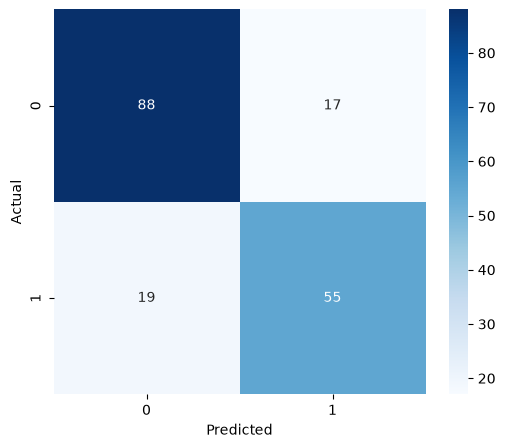

In [89]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [90]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [91]:
import joblib 

metadata = {
    "accuracy": accuracy,
    "features": list(X.columns)
}

joblib.dump(metadata, "../models/metadata.pkl")
joblib.dump(model, "../models/logistic-model.pkl")

['../models/logistic-model.pkl']

In [92]:
X.columns

Index(['Pclass', 'Sex', 'Age', 'Fare', 'Embarked_Q', 'Embarked_S'], dtype='str')